<a href="https://colab.research.google.com/github/SSenitha/Data_Analytics/blob/WorkSpace_Dilini/Descriptive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [104]:
df = pd.read_csv('https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv')

In [105]:
df.head(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null



*   We can see that the dataset contains mixture of categorical and numerical variables.
*   Categorical variables have data type object.


*   Numerical variables have data type float64.
*   Also, there are some missing values in the dataset.








# **Data Duplication Handeling**


In [107]:
# Check for duplicate rows and removing, keeping the first occurrence
print(df.duplicated().sum())
df_cleaned = df.drop_duplicates()

0


# **Null Value Handeling**

In [108]:
# Check for the missing values
missing_values_count = df.isnull().sum()
print(missing_values_count)

# Calculate the percent of data that is missing
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
print(f"Percentage of missing values: {percent_missing}")

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64
Percentage of missing values: 10.259745694319072


In [109]:
df_cleaned = df

# Remove the rows that has missing result
df_cleaned.dropna(subset=['RainToday'], inplace=True)
df_cleaned.dropna(subset=['RainTomorrow'], inplace=True)
#print(df.head())

# Check the remaining value count
print(f"Total rows Left: {df['RainToday'].count()}")

Total rows Left: 140787


In [110]:
numerical_cols = df.select_dtypes(include=['float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna('')

# **Standardization**

**Convert Date datatype (object → datetime)** - This helps for treating dates as dates, not just as text.

In [111]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
print("\nParsed 'Date' column. Example values:")
print(df['Date'].head())


Parsed 'Date' column. Example values:
0   2008-01-12
1   2008-02-12
2   2008-03-12
3   2008-04-12
4   2008-05-12
Name: Date, dtype: datetime64[ns]


In [112]:
# extract the day, month, and year components
df_cleaned['Day'] = df_cleaned['Date'].dt.day
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Year'] = df_cleaned['Date'].dt.year

**Removing unwanted columns**

In [113]:
df_cleaned.drop(['Date'], axis=1, inplace=True)
df_cleaned.drop(['WindGustDir'], axis=1, inplace=True)
df_cleaned.drop(['WindDir9am'], axis=1, inplace=True)
df_cleaned.drop(['WindDir3pm'], axis=1, inplace=True)

**Map binary variables**

In [114]:

#df_cleaned['RainTomorrow'] = df_cleaned['RainTomorrow'].map({'Yes': 1, 'No': 0})
#df_cleaned['RainToday'] = df_cleaned['RainToday'].map({'Yes': 1, 'No': 0})

**Change the data type 'object' to 'category'** - This helps to tell Python/statistics that it’s a categorical variable, improves memory, speed, and modeling.

In [115]:
# Identify object dtype columns
object_cols = df.select_dtypes(include=['object']).columns

# Convert object columns to category
df[object_cols] = df[object_cols].astype('category')

# Check updated dtypes
print(df.dtypes)

Location         category
MinTemp           float64
MaxTemp           float64
Rainfall          float64
Evaporation       float64
Sunshine          float64
WindGustSpeed     float64
WindSpeed9am      float64
WindSpeed3pm      float64
Humidity9am       float64
Humidity3pm       float64
Pressure9am       float64
Pressure3pm       float64
Cloud9am          float64
Cloud3pm          float64
Temp9am           float64
Temp3pm           float64
RainToday        category
RainTomorrow     category
Day               float64
Month             float64
Year              float64
dtype: object


In [116]:
df.shape

(140787, 22)

# **Descriptive Analysis**

**View statistical properties of dataset**

In [117]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Day,Month,Year
count,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,55553.000000,55553.000000,55553.000000
mean,12.184209,23.233735,2.349974,5.187367,8.043108,39.907754,13.983074,18.637772,68.839474,51.462983,1017.649250,1015.252294,4.643788,4.698765,16.985729,21.682127,6.380736,6.493853,2012.770021
std,6.393235,7.106800,8.465173,3.196637,2.775557,13.133963,8.853265,8.718790,18.961051,20.547147,6.749208,6.682548,2.300772,2.123656,6.480890,6.873294,3.425716,3.452234,2.547510
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,1.000000,1.000000,2007.000000
25%,7.600000,17.900000,0.000000,4.000000,8.200000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.000000,3.000000,4.000000,12.300000,16.700000,3.000000,3.000000,2011.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,6.000000,6.000000,2013.000000
75%,16.800000,28.200000,0.800000,5.400000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.300000,9.000000,9.000000,2015.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,12.000000,12.000000,2017.000000


In [118]:
# Select only categorical (category) columns
cat_cols = df.select_dtypes(include=['category']).columns

# Summary for each categorical column
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))   # include NaN counts
    print("-" * 40)



Column: Location
Location
Canberra            3402
Sydney              3331
Perth               3193
Darwin              3192
Hobart              3183
Brisbane            3132
Bendigo             3030
Townsville          3027
AliceSprings        3025
MountGambier        3022
Adelaide            3020
Launceston          3020
Ballarat            3017
MelbourneAirport    3009
PerthAirport        3009
Mildura             3005
SydneyAirport       3001
Albany              2996
Nuriootpa           2996
Sale                2992
Albury              2991
Watsonia            2990
Portland            2984
Woomera             2984
Cobar               2980
Cairns              2964
Tuggeranong         2959
WaggaWagga          2958
NorfolkIsland       2944
Wollongong          2943
SalmonGums          2941
CoffsHarbour        2940
Dartmoor            2939
Newcastle           2929
Witchcliffe         2924
GoldCoast           2924
Penrith             2911
Richmond            2906
NorahHead           288

**Explore *RainTomorrow* target variable**

Check for missing values



In [119]:
# Count null values in target variable
null_count = df['RainTomorrow'].isnull().sum()

print(f"Number of null values in RainTomorrow: {null_count}")


Number of null values in RainTomorrow: 0


View the unique values

In [120]:
df['RainTomorrow'].unique()

['No', 'Yes']
Categories (2, object): ['No', 'Yes']

View the frequency distribution of values

In [127]:
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
No,109586
Yes,31201


In [124]:
df['RainTomorrow'].value_counts()/len(df)

,count
RainTomorrow,
No,0.778382
Yes,0.221618




*   We can see that out of the total number of RainTomorrow values, No appears 77.83% times and Yes appears 22.16% times.



## **Categorical Variables Analysis**

Visualize frequency distribution of RainTomorrow variable

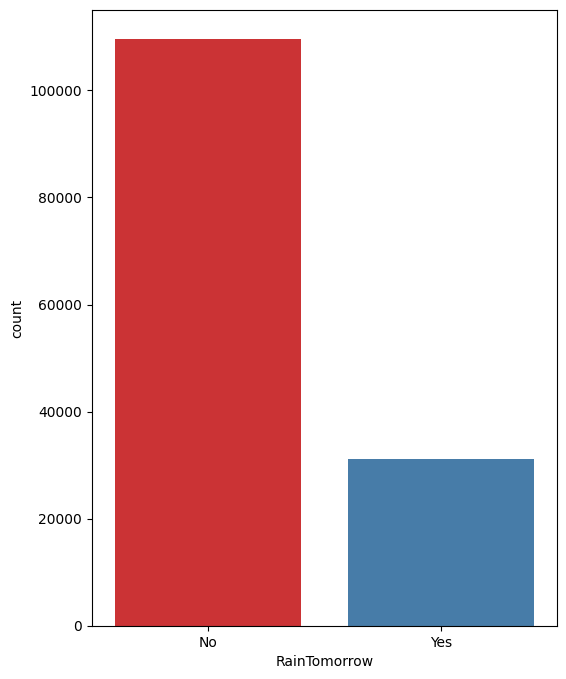

In [126]:
f, ax = plt.subplots(figsize=(6, 8))
ax = sns.countplot(x="RainTomorrow", data=df, palette="Set1", hue="RainTomorrow", legend=False)
plt.show()



*   The No variable have 109586 entries, and
*   The Yes variable have 31201
entries.



Location vs RainTomorrow (grouped by Yes/No)

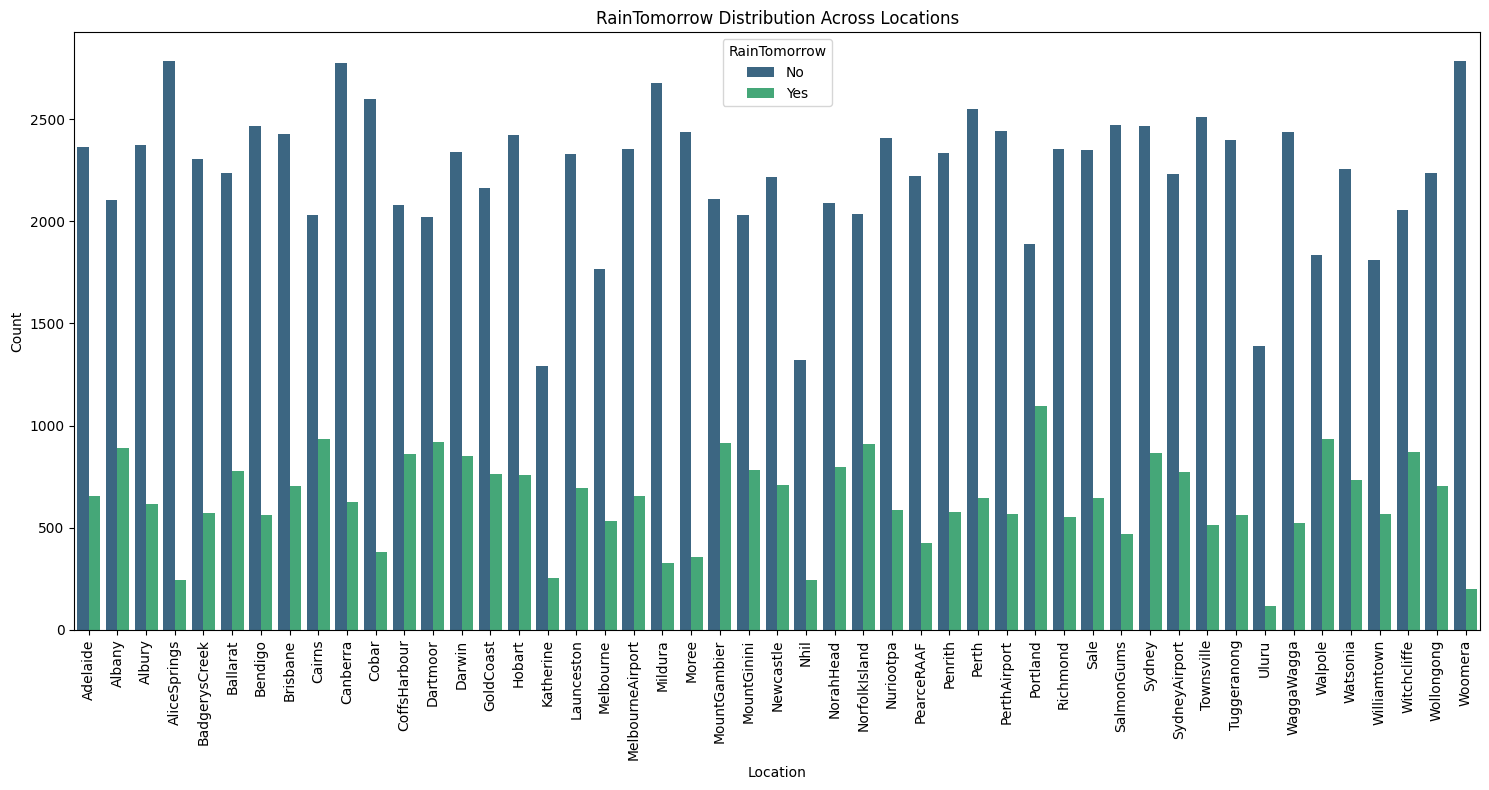

In [132]:
plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='Location', hue='RainTomorrow', palette='viridis')

plt.ylabel('Count')
plt.xticks(rotation=90)
plt.title('RainTomorrow Distribution Across Locations')
plt.tight_layout()
plt.show()

RainToday vs RainTomorrow (to see correlation between consecutive days)

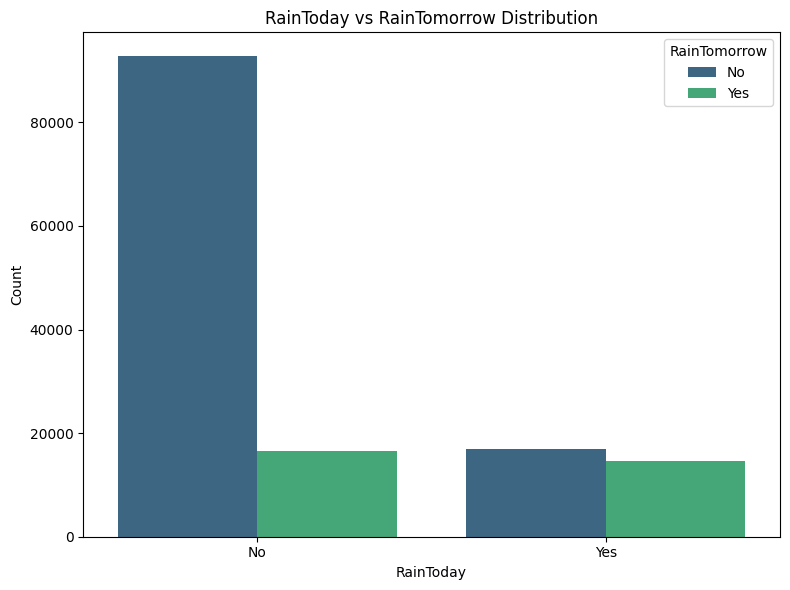

In [134]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='RainToday', hue='RainTomorrow', palette='viridis')

plt.ylabel('Count')
plt.title('RainToday vs RainTomorrow Distribution')
plt.tight_layout()
plt.show()

Monthly rain patterns (Month vs RainTomorrow percentage)

/tmp/ipython-input-3896996406.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_rain = df.groupby(['Month', 'RainTomorrow']).size().unstack(fill_value=0)


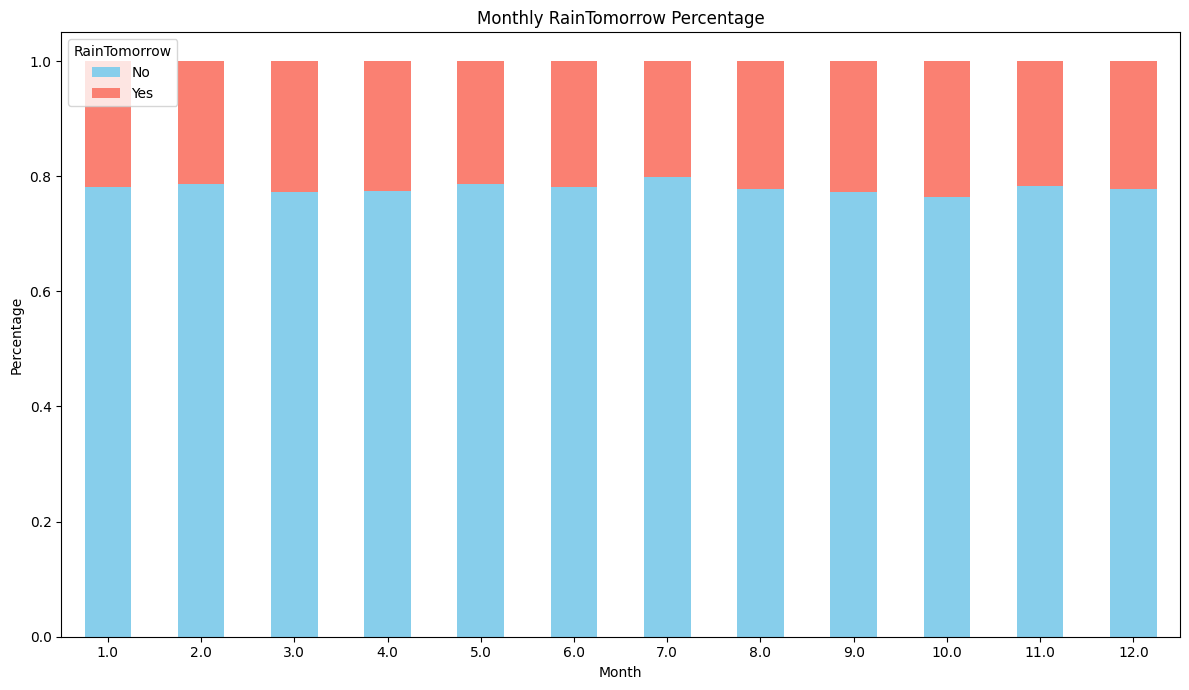

In [135]:
# Calculate the count of RainTomorrow for each month
monthly_rain = df.groupby(['Month', 'RainTomorrow']).size().unstack(fill_value=0)

# Calculate the percentage of RainTomorrow for each month
monthly_rain_percent = monthly_rain.apply(lambda x: x / x.sum(), axis=1)

# Create a stacked bar chart
monthly_rain_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=['skyblue', 'salmon'])

plt.title('Monthly RainTomorrow Percentage')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

Yearly trends (Year vs RainTomorrow percentage)

/tmp/ipython-input-3091822865.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_rain = df.groupby(['Year', 'RainTomorrow']).size().unstack(fill_value=0)


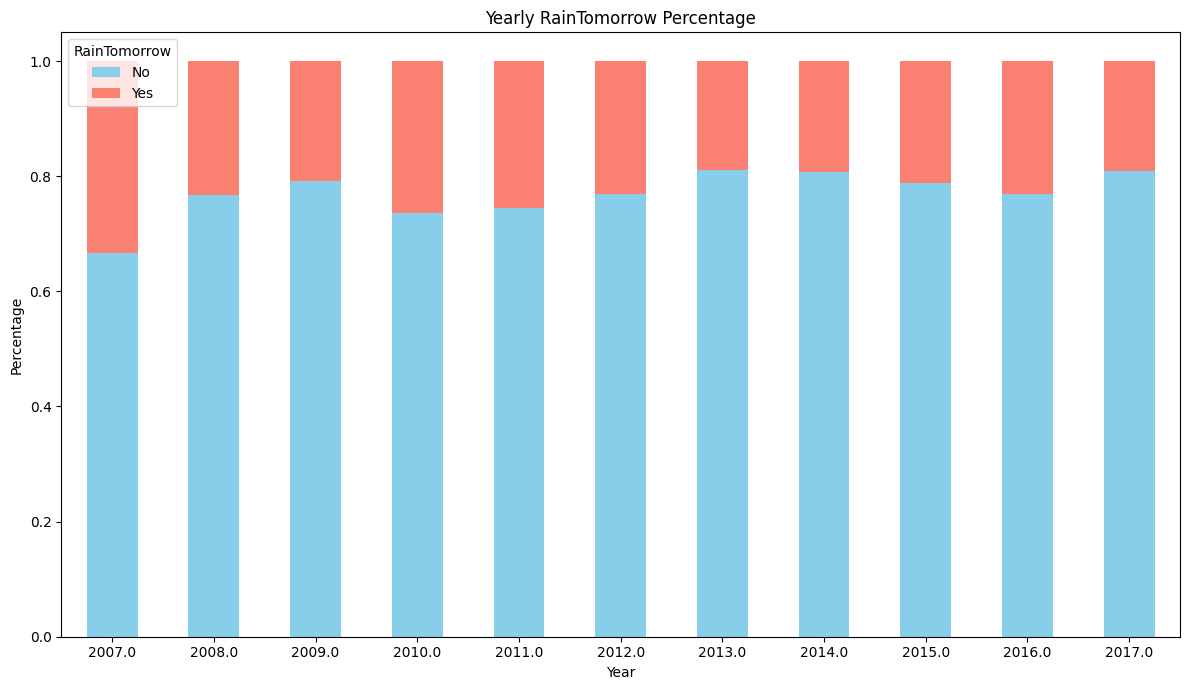

In [136]:
# Calculate the count of RainTomorrow for each year
yearly_rain = df.groupby(['Year', 'RainTomorrow']).size().unstack(fill_value=0)

# Calculate the percentage of RainTomorrow for each year
yearly_rain_percent = yearly_rain.apply(lambda x: x / x.sum(), axis=1)

# Create a stacked bar chart
yearly_rain_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=['skyblue', 'salmon'])

plt.title('Yearly RainTomorrow Percentage')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

# **Numerical Variables Distribution**

Rainfall distribution by RainTomorrow

/tmp/ipython-input-287696767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='RainTomorrow', y='Rainfall', palette='viridis')


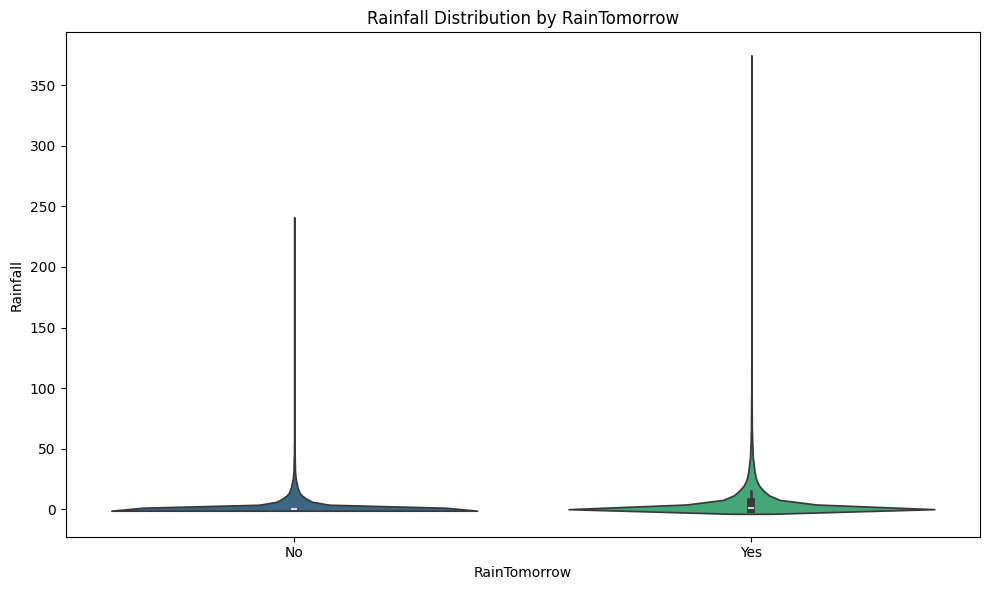

In [138]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='RainTomorrow', y='Rainfall', palette='viridis')
plt.title('Rainfall Distribution by RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Rainfall')
plt.tight_layout()
plt.show()

Temperature variables (MinTemp, MaxTemp, Temp9am, Temp3pm) distribution with RainTomorrow

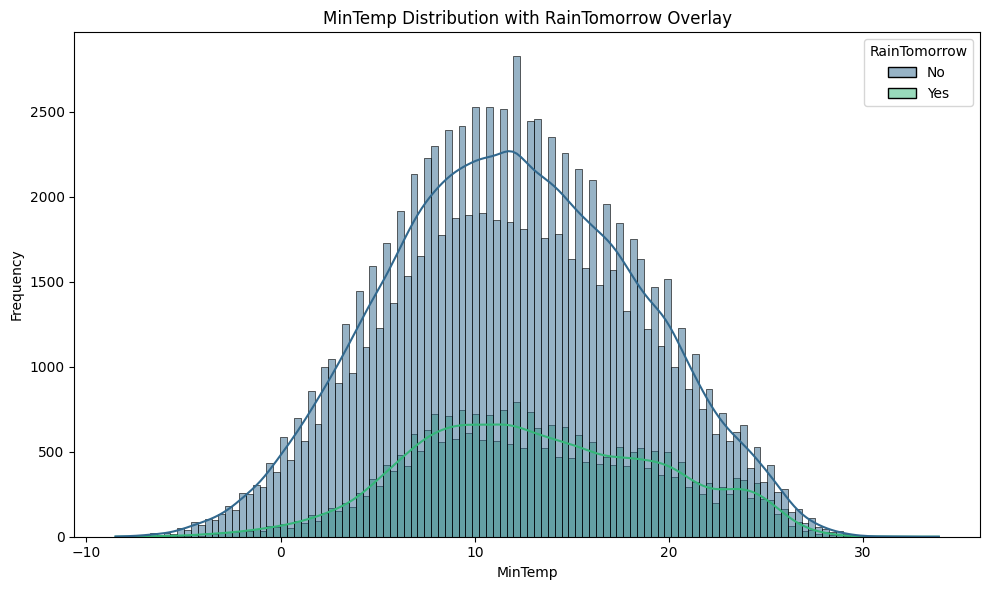

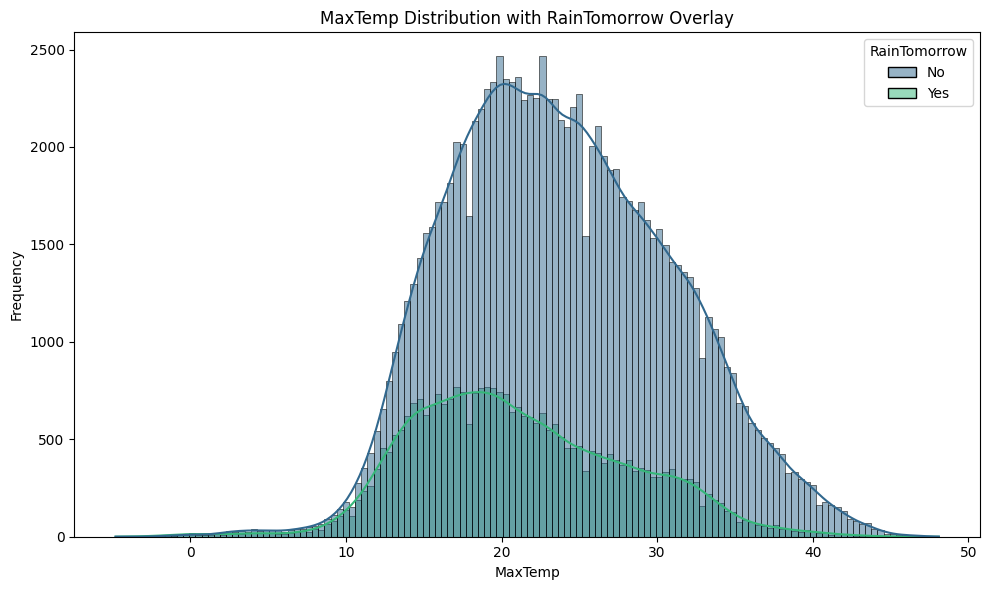

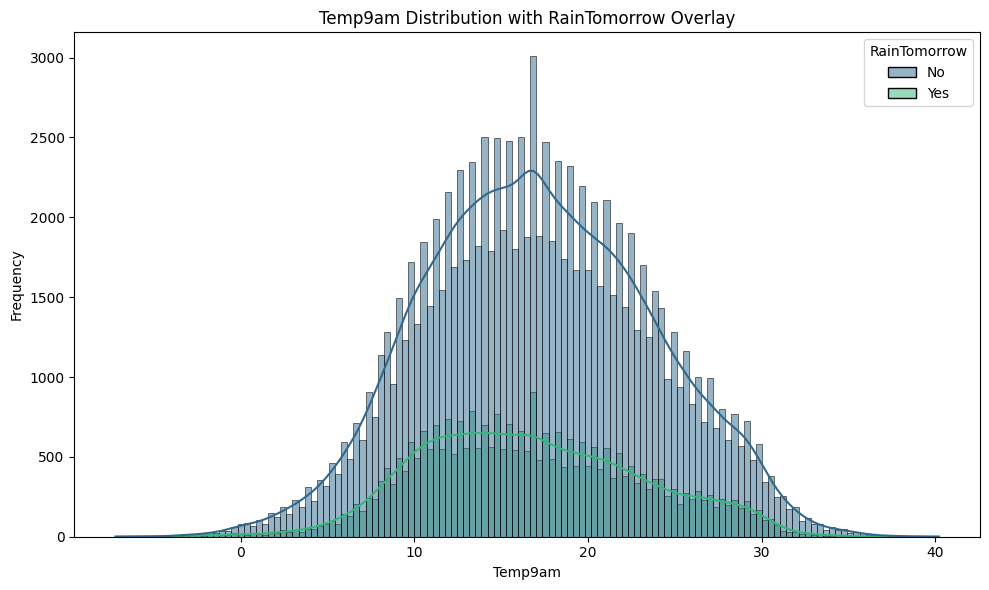

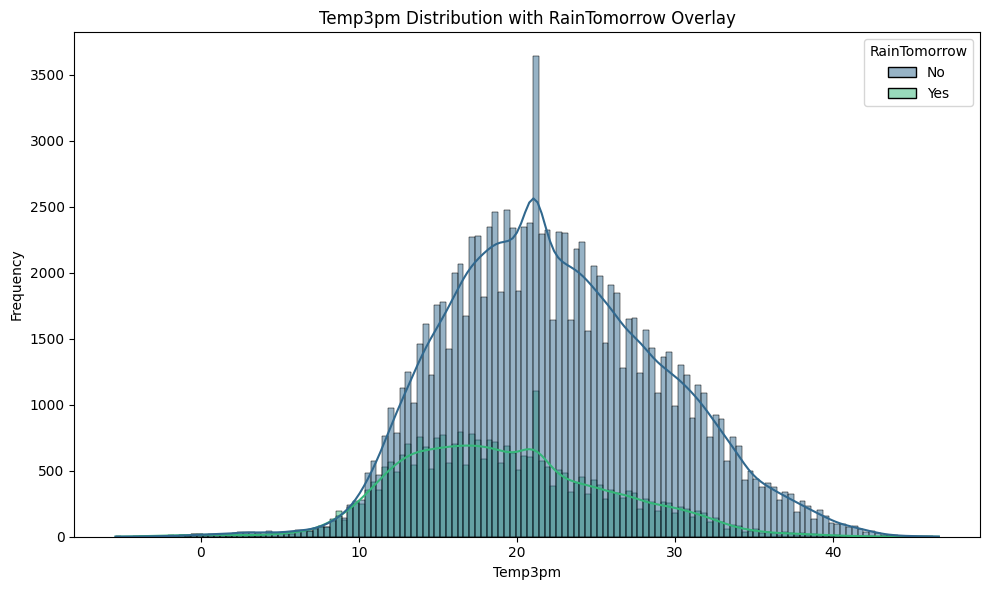

In [139]:
temp_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']

for col in temp_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='RainTomorrow', palette='viridis', kde=True)
    plt.title(f'{col} Distribution with RainTomorrow Overlay')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

Humidity variables (Humidity9am, Humidity3pm) distribution with RainTomorrow

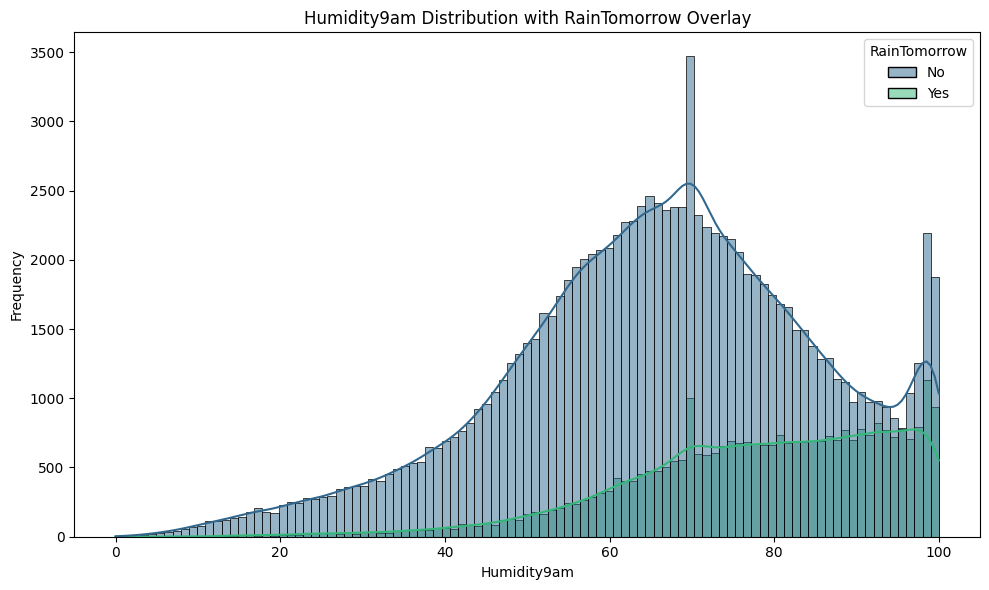

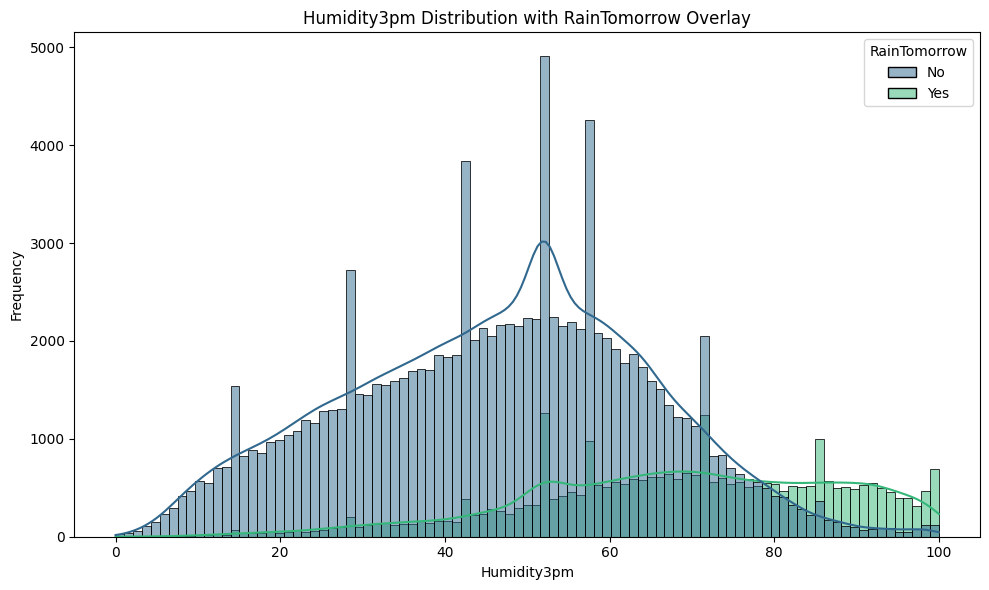

In [140]:
humidity_cols = ['Humidity9am', 'Humidity3pm']

for col in humidity_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='RainTomorrow', palette='viridis', kde=True)
    plt.title(f'{col} Distribution with RainTomorrow Overlay')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

Pressure9am\Pressure3pm distribution by RainTomorrow

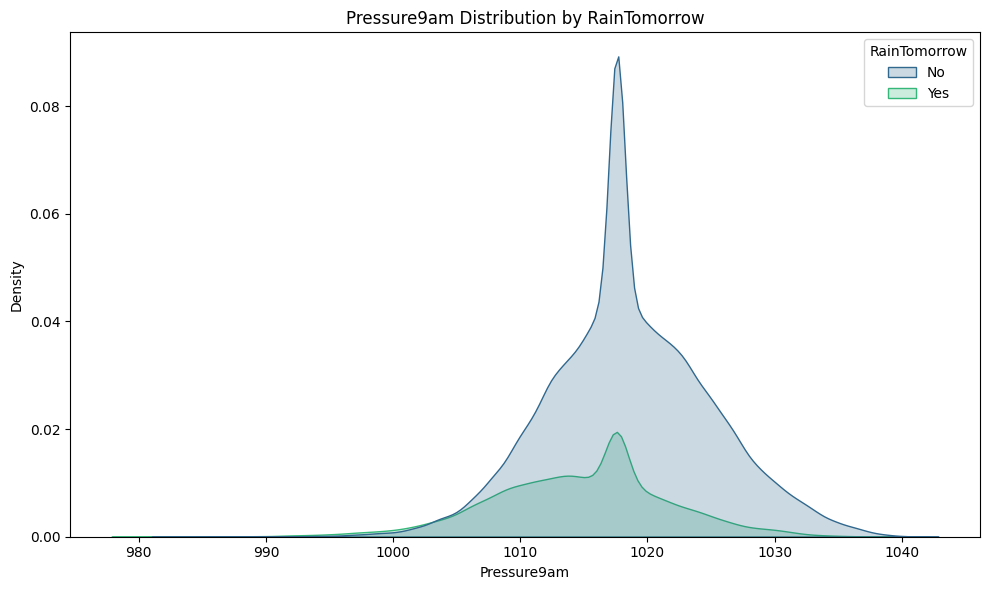

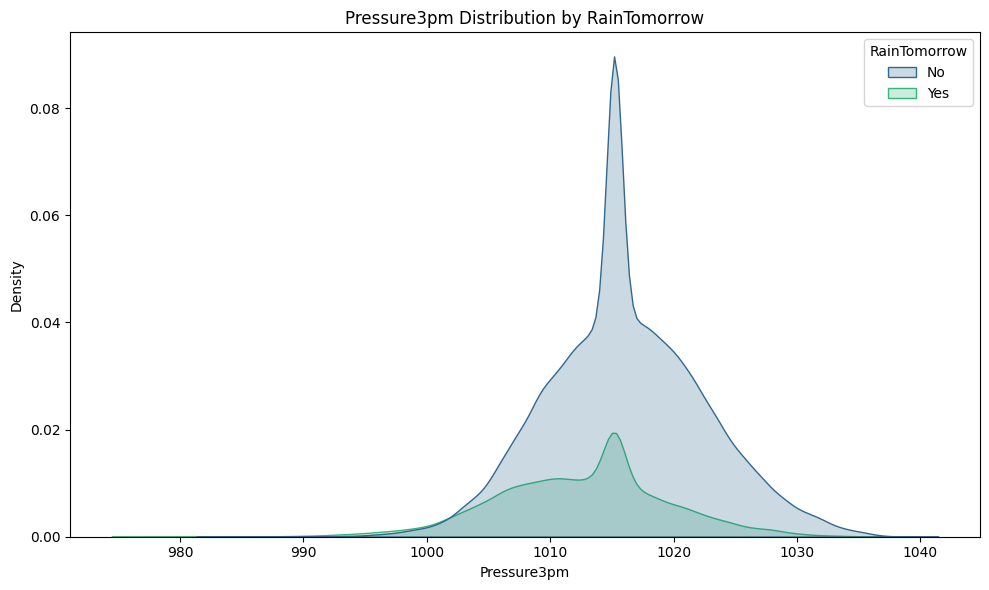

In [141]:
pressure_cols = ['Pressure9am', 'Pressure3pm']

for col in pressure_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x=col, hue='RainTomorrow', palette='viridis', fill=True)
    plt.title(f'{col} Distribution by RainTomorrow')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

WindGustSpeed Distribution by RainTomorrow

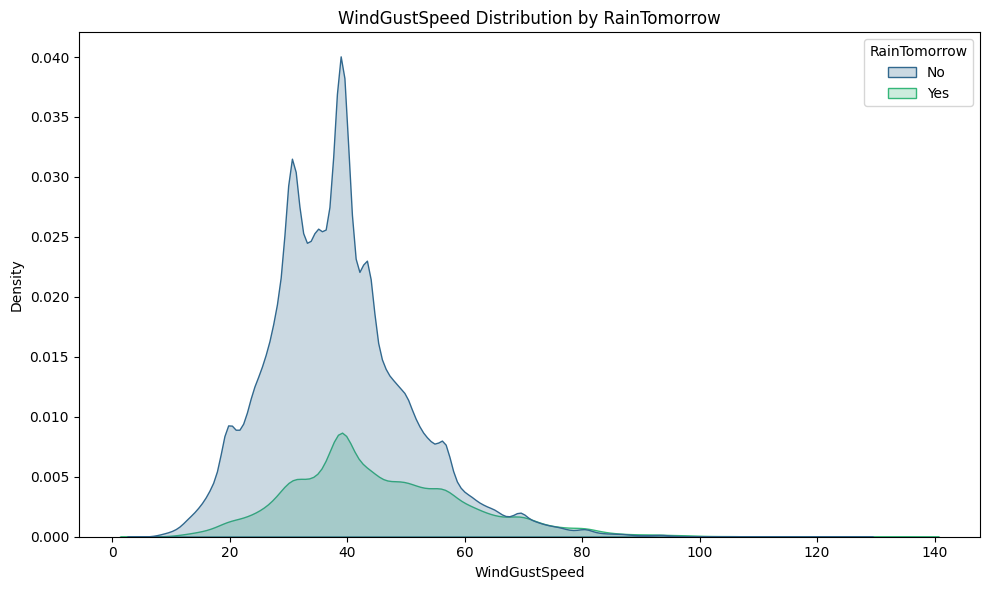

In [142]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='WindGustSpeed', hue='RainTomorrow', palette='viridis', fill=True)
plt.title('WindGustSpeed Distribution by RainTomorrow')
plt.xlabel('WindGustSpeed')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Evaporation and Sunshine Distribution by RainTomorrow

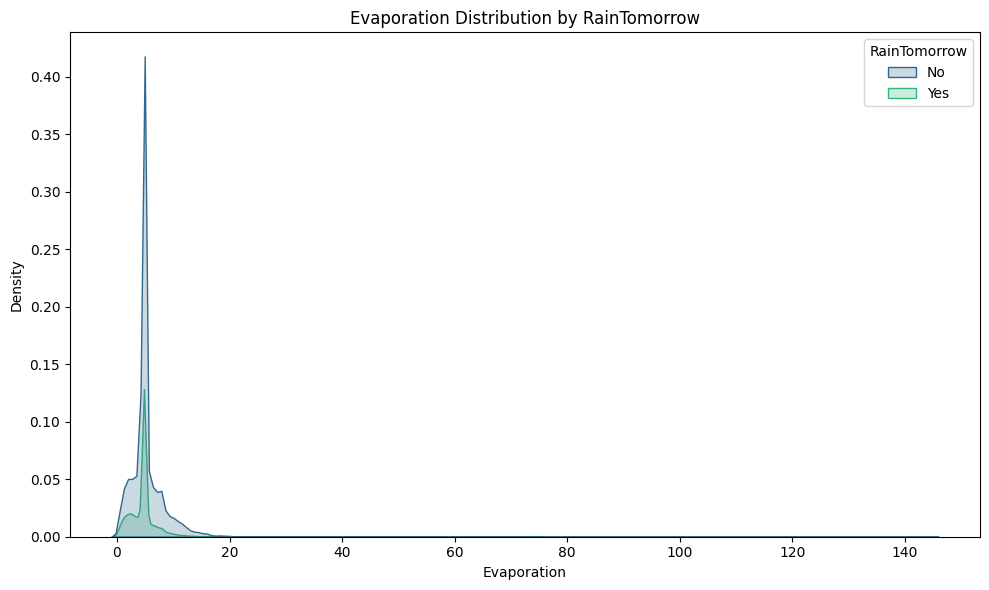

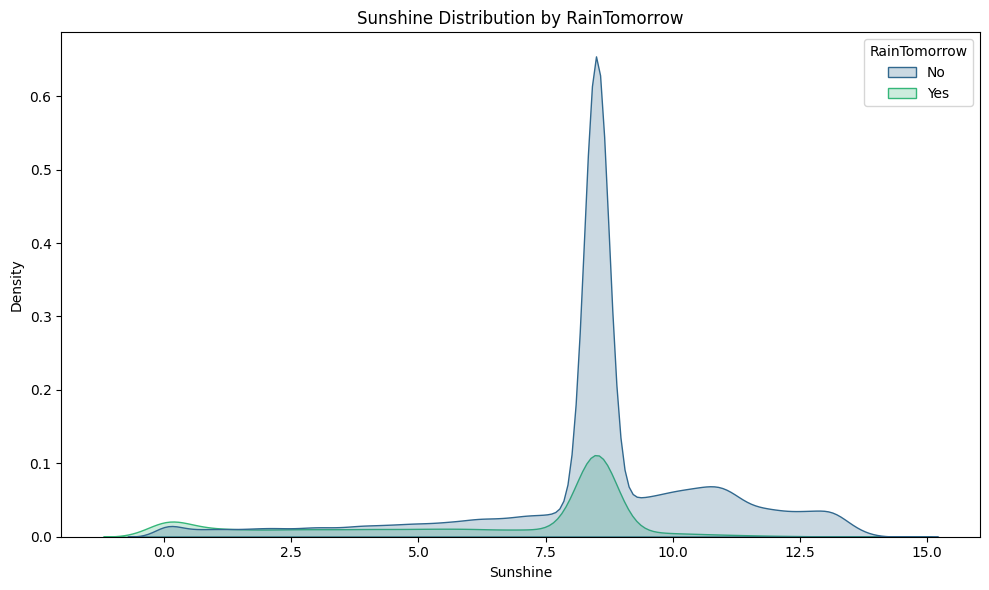

In [143]:
other_cols = ['Evaporation', 'Sunshine']

for col in other_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x=col, hue='RainTomorrow', palette='viridis', fill=True)
    plt.title(f'{col} Distribution by RainTomorrow')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()